Translation of matlab program for Laffer curve model

Demand for the currency of a small country satisfies the Cagan-like demand function

$$
m_t^d/p_t =\gamma_1 - \gamma_2 \frac{p_{t+1}}{p_t}, \quad t \geq 0
$$

where 

   * $m_t^d$ is the demand for currency at time $t$
   * $p_t$ is the price level at time $t$
   
   
   
The supply of money is determined by the government's budget constraint

$$
m_t - m_{t-1} = p_t g 
$$

where
  * $m_t$ is the supply of currency at the end of time $t$
  * $m_{-1}$ is the initial stock of currency brought into time $0$
  * $g$ is the government deficit that is financed by printing currency
  
## The Laffer Curve


$$
\frac{m_t}{p_t} - \frac{m_{t-1}}{p_{t-1}} \frac{p_{t-1}}{p_t} = g
$$

or

$$
b_t - b_{t-1} R_{t-1} = g
$$

where

  * $b_t = \frac{m_t}{p_t}$ is real balances at the end of period $t$
  * $R_t{t-1} = \frac{p_{t-1}}{p_t}$ is the gross rate of return on real balances held from $t-1$ to $t$
  
We'll restrict parameter values and our attention to rates of return on real balances that assure that the demand for real balances
is positive, which according to (1) means that

$$
b_t = \gamma_1 - \gamma_2 R_t^{-1} > 0 
$$

which implies that

$$
R_t \geq \frac{\gamma_2}{\gamma_1}
$$




### Steady States

We seek steady state values $\bar R, \bar b$ that satisfy both the government budget constraint and the demand function for real balances:

\begin{align}
g & = \bar b ( 1 - \bar R)  \cr
\bar b & = \gamma_1- \gamma_2 \bar R^{-1}
\end{align}

which together imply

$$
(\gamma_1 + \gamma_2) - \frac{\gamma_2}{\bar R} - \gamma_1 \bar R = g
$$


The left side is the steady-state amount of **seigniorage** or government revenues that the government reaps by offering a gross rate of return 
$\bar R < 1$. 

The right side is government expenditures.

If we maximize seigniorage with respect to $\bar R$, we find maximizing rate of return on currency is 

$$
\bar R_{\rm max} = \sqrt{\frac{\gamma_2}{\gamma_1}}
$$

and that the associated revenue is

It is useful to rewrite the above equation as

$$
-\gamma_2 + (\gamma_1 + \gamma_2 0 g) \bar R - \gamma_1 \bar R^2 = 0
$$

A steady state value $\bar R$ is a zero of this quadratic equation.

So there  are typically two steady state values of $\bar R$. 


##
  

## Dynamics
 
An **equilibrium** is pair of sequences $(\vec p, \vec m ) = \{p_t, m_t\}_{t=0}^\infty$ satisfying (1) and (2) and $m_t = m_t^d$ for all $t \geq 0$. 


Set $m_t = m_t^d $ for all $t \geq -1$, and represent equations (1) and (2) as

$$
\begin{bmatrix} 1 & \gamma_2 \cr
                 1 & 0 \end{bmatrix} \begin{bmatrix} m_t \cr p_{t+1} \end{bmatrix} =
                 \begin{bmatrix} 0 & 1 \cr
                 1 & g \end{bmatrix} \begin{bmatrix} m_{t-1} \cr p_{t} \end{bmatrix} 
$$

or

$$ 
L y_t = N y_{t-1} 
$$

where 

\begin{align} L & = \begin{bmatrix} 1 & \gamma_2 \cr
                 1 & 0 \end{bmatrix} \cr
                N & = \begin{bmatrix} 0 & 1 \cr
                 1 & g \end{bmatrix}  \cr
                 y_t & = \begin{bmatrix} m_{t-1} \cr p_{t} \end{bmatrix}
\end{align}

Define

$$
M = L^{-1} N
$$

and write the system as

$$
y_{t+1} = M y_t, \quad t \geq 0
$$

where 

$$
y_0 = \begin{bmatrix} m_{-1} \cr p_0 \end{bmatrix}
$$


To find the smallest equilibrium  $p_0$, we use the invariant subspace methods described in section 5.6 of RMT5.  

Compute the eigenvector decomposition 

$$
M = V D V^{-1}
$$ 

where $D$ is a diagonal matrix of eigenvalues and the columns of $V$ are eigenvectors correspondng to those eigenvalues.

Partition $V$ as

$$ 
V =\begin{bmatrix} V_{11} & V_{12} \cr
                   V_{21} & V_{22} \end{bmatrix}
$$

Then set 


$$
p_0 = V_{21} V_{11}^{-1}  m_{-1}
$$


## An insert for above

Where $b_t = \frac{m_t}{p_t}$, we have 

$$
b_0 = \gamma_1 - \gamma_0 R_0 
$$

where 

$$
m_0 = m_{-1} + g p_0
$$


Combine these to get

$$
\frac{m_{-1}}{p_0} = \gamma_1 - \gamma_2 R_0
$$

Solving this equation for $p_0$ gives

$$
p_0 = \frac{\gamma_1 - m_{-1}}{g + \gamma_1} R_0
$$

Starting at $t=0$ with  a given $R_0$ and  $b_0 = \gamma_1 - \gamma_0 R_0 $ at time $0$, for $t \geq 1$ construct $b_t, R_t$ by
iterating  on the system 
\begin{align}
b_t & = b_{t-1} R_{t-1} + g \cr
R_t^{-1} & = \frac{\gamma_1}{\gamma_2} - \gamma_2^{-1} b_t
\end{align}

In [16]:
import numpy as np

gam1 = 100
gam2 = 50
g = 3.0
M0 = 100

m1 = np.array([[1, gam2], [1, 0]])  # This is $L$
m2 = np.array([[0, gam1], [1, g]])  # This is $N$

m1, m2

print("m1 = ", m1)

print("m2 = ", m2)

M = np.linalg.inv(m1) @ m2

print("M = ", M)

d, v = np.linalg.eig(np.linalg.inv(m1) @ m2)
v, d


d = np.diag(d)

#v = np.linalg.inv(w)

#print("w = ", w)
print("d = ", d)

#print("v = ", v)


print (d)

a1 = v @ d @ np.linalg.inv(v)

print("M = ", M)
print("a1 = ", a1)

a10 = v @ np.linalg.matrix_power(d, 10) @ np.linalg.inv(v)
M10 = np.linalg.matrix_power(M,10)

print("M10= ",M10)
print("a10= ", a10)

p0 = (v[1, 0] / v[0, 0]) * M0
#p0 = -(v[1, 1] / v[1, 0] )* M0
#p0 = - (v[1,0]/v[1,1])*M0

x0 = np.array([M0, p0])

y0 = np.array([M0, p0])

print("p0 =", p0)
print("x0 =", x0)
print("y0 =", y0)

x1 = a1 @ x0
x10 = a10 @ x0

pp0 = p0 + 1
xx0 = x0.copy()
xx0[1] = pp0 + 1

xx1 = a1 @ xx0
xx10 = a10 @ xx0

print("x0:", x0)
print("x1:", x1)
print("x10:", x10)
print("xx0:", xx0)
print("xx1:", xx1)
print("xx10:", xx10)

m1 =  [[ 1 50]
 [ 1  0]]
m2 =  [[  0. 100.]
 [  1.   3.]]
M =  [[ 1.    3.  ]
 [-0.02  1.94]]
d =  [[1.06887658 0.        ]
 [0.         1.87112342]]
[[1.06887658 0.        ]
 [0.         1.87112342]]
M =  [[ 1.    3.  ]
 [-0.02  1.94]]
a1 =  [[ 1.    3.  ]
 [-0.02  1.94]]
M10=  [[ -43.0498124  1959.87122076]
 [ -13.06580814  571.0431701 ]]
a10=  [[ -43.0498124  1959.87122076]
 [ -13.06580814  571.0431701 ]]
p0 = 2.295885919912281
x0 = [100.           2.29588592]
y0 = [100.           2.29588592]
x0: [100.           2.29588592]
x1: [106.88765776   2.45401868]
x10: [194.65950037   4.46916006]
xx0: [100.           4.29588592]
xx1: [112.88765776   6.33401868]
xx10: [4114.40194189 1146.55550027]


In [17]:
d

array([[1.06887658, 0.        ],
       [0.        , 1.87112342]])

In [33]:
coeff2 = (-gam1, (gam1+gam2-g), -gam2)
coeff = (-gam2, (gam1+gam2 -g),- gam1)

RR = np.roots(coeff)
print("RR = ", RR)
RR2 = np.roots(coeff2)
print("RR2 = ", RR2)

Rmaxguess = 1/RR[1]
Rminguess = 1/RR[0]
print("Rmaxguess = ", Rmaxguess)
print("Rminguess = ", Rminguess)
p0guess = M0/(gam1 - gam2/Rmaxguess)
print("p0guess =", p0guess)


RR =  [1.87112342 1.06887658]
RR2 =  [0.93556171 0.53443829]
Rmaxguess =  0.9355617112013157
Rminguess =  0.5344382887986843
p0guess = 2.1479429599561404


In [19]:

##coeff = (-gam1, (gam1+gam2-g), -gam2)
np.roots(coeff)

array([1.87112342, 1.06887658])

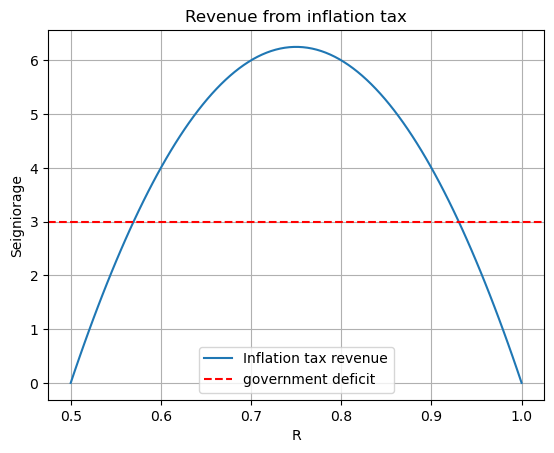

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def seign(R, gam1=1, gam2=2, g=3):
    return -gam2 + (gam1 + gam2 ) * R - gam1 * R**2

# Generate values for R
R_values = np.linspace(gam2/gam1, 1, 100)  # Adjust the range and number of points as needed

# Default parameter values
gam1_default = 100
gam2_default = 50
g_default = 3

# Calculate the function values
y_values = seign(R_values, gam1_default, gam2_default, g_default)

# Plot the function
plt.plot(R_values, y_values, label='Inflation tax revenue')
plt.axhline(y=g_default, color='red', linestyle='--', label='government deficit')
plt.xlabel('R')
plt.ylabel('Seigniorage')
plt.title('Revenue from inflation tax')
plt.legend()
plt.grid(True)
plt.show()


In [21]:
Rmax = np.sqrt(gam2/gam1)
print("Rmax = ", Rmax)
seign(Rmax, gam1_default, gam2_default, g_default)



Rmax =  0.7071067811865476


6.066017177982118

In [22]:
m1

array([[ 1, 50],
       [ 1,  0]])

In [23]:
m2

array([[  0., 100.],
       [  1.,   3.]])

In [24]:
np.linalg.cond(m1)

50.020007999998704

In [25]:
M

array([[ 1.  ,  3.  ],
       [-0.02,  1.94]])

In [26]:
M@M

array([[ 0.94  ,  8.82  ],
       [-0.0588,  3.7036]])

In [29]:
#gam1 = 100
#gam2 = 50
#g = 3.0
#M0 = 100



def simulate_system(R0, gam1, gam2, g, num_steps):
    # Initialize arrays to store results
    b_values = [gam1 - gam2 / R0]
    R_values = [1 / ((gam1 / gam2) - (gam2**(-1) * b_values[0]))]

    # Iterate over time steps
    for t in range(1, num_steps):
        # Calculate b_t and R_t based on the given formulas
        b_t = b_values[t - 1] * R_values[t - 1] + g
        R_t_inverse = (gam1 / gam2) - gam2**(-1) * b_t
        R_values.append(1 / R_t_inverse)
        b_values.append(b_t)

    return b_values, R_values

# Parameters
R0 = Rmaxguess -.01

num_steps = 25

# Run simulation
b_values, R_values = simulate_system(R0, gam1, gam2, g, num_steps)

# Print results
for t in range(num_steps):
    print(f"Time step {t}: b_t = {b_values[t]}, R_t = {R_values[t]}")


Time step 0: b_t = 45.97875063878407, R_t = 0.9255617112013157
Time step 1: b_t = 45.55617112013157, R_t = 0.9183777303820082
Time step 2: b_t = 44.83777303820082, R_t = 0.9064173575629187
Time step 3: b_t = 43.64173575629187, R_t = 0.8871813330479217
Time step 4: b_t = 41.718133304792175, R_t = 0.8578997694339671
Time step 5: b_t = 38.78997694339671, R_t = 0.8168596825027015
Time step 6: b_t = 34.68596825027015, R_t = 0.7655322854909627
Time step 7: b_t = 29.55322854909628, R_t = 0.7097557342971547
Time step 8: b_t = 23.975573429715464, R_t = 0.6576833559379106
Time step 9: b_t = 18.76833559379107, R_t = 0.6155235198674356
Time step 10: b_t = 14.552351986743554, R_t = 0.5851536134996126
Time step 11: b_t = 11.515361349961257, R_t = 0.565069833169038
Time step 12: b_t = 9.506983316903796, R_t = 0.5525288230261842
Time step 13: b_t = 8.252882302618424, R_t = 0.5449762483538704
Time step 14: b_t = 7.49762483538704, R_t = 0.5405266611913727
Time step 15: b_t = 7.052666119137272, R_t = 0.5

In [ ]:
#gam1 = 100
#gam2 = 50
#g = 3.0
#M0 = 100



def simulate_system(R0, gam1, gam2, g, num_steps):
    # Initialize arrays to store results
    b_values = [gam1 - gam2 * R0]
    R_values = [1 / ((gam1 / gam2) - (gam2**(-1) * b_values[0]))]

    # Iterate over time steps
    for t in range(1, num_steps):
        # Calculate b_t and R_t based on the given formulas
        b_t = b_values[t - 1] * R_values[t - 1] + g
        R_t_inverse = (gam1 / gam2) - gam2**(-1) * b_t
        R_values.append(1 / R_t_inverse)
        b_values.append(b_t)

    return b_values, R_values

# Parameters
R0 = .7

num_steps = 25

# Run simulation
b_values, R_values = simulate_system(R0, gam1, gam2, g, num_steps)

# Print results
for t in range(num_steps):
    print(f"Time step {t}: b_t = {b_values[t]}, R_t = {R_values[t]}")
